# 1. Mount Google Drive

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
import os

project_path = "/content/drive/MyDrive/Study/HKU/POLI3148 Data Science in Politics and Public Administration/Final Project/"

if os.path.exists(project_path):
    print("Path found:", project_path)
    print("\nContents:")
    for item in os.listdir(project_path):
        print("-", item)
else:
    print("Path not found:", project_path)

Path found: /content/drive/MyDrive/Study/HKU/POLI3148 Data Science in Politics and Public Administration/Final Project/

Contents:
- Report
- Data
- Code
- Prompt
- .vscode
- .venv
- .git
- docs
- GITHUB_PAGES.md
- .gitignore
- x.log
- texput.log
- README.md


# 2. 爬取中联办资料

## 2.1 国家领导人重要涉港活动·讲话（简体）

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [4]:
!pip install selenium beautifulsoup4 pandas webdriver-manager

In [5]:
# 移除旧安装（如果有）并安装兼容的无头浏览器
!apt-get update
!apt-get install -y wget unzip
!wget -q -O - https://dl-ssl.google.com/linux/linux_signing_key.pub | apt-key add -
!sh -c 'echo "deb [arch=amd64] http://dl.google.com/linux/chrome/deb/ stable main" >> /etc/apt/sources.list.d/google-chrome.list'
!apt-get update
!apt-get install -y google-chrome-stable

Hit:1 http://dl.google.com/linux/chrome/deb stable InRelease
Get:2 https://dl.google.com/linux/chrome-stable/deb stable InRelease [1,825 B] 
Hit:3 https://cli.github.com/packages stable InRelease                         
Hit:4 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease     
Hit:5 http://archive.ubuntu.com/ubuntu jammy InRelease                         
Hit:6 http://security.ubuntu.com/ubuntu jammy-security InRelease               
Get:7 https://dl.google.com/linux/chrome-stable/deb stable/main amd64 Packages [1,220 B]
Hit:8 http://archive.ubuntu.com/ubuntu jammy-updates InRelease                 
Hit:9 http://archive.ubuntu.com/ubuntu jammy-backports InRelease               
Get:10 https://r2u.stat.illinois.edu/ubuntu jammy InRelease [6,555 B]          
Get:11 https://r2u.stat.illinois.edu/ubuntu jammy/main amd64 Packages [2,991 kB]
Get:12 https://r2u.stat.illinois.edu/ubuntu jammy/main all Packages [10.1 MB]  
Ign:13 https://ppa.launchpadcontent.net/deadsnake

In [6]:
import pandas as pd
import time
import os
import requests
import json
from bs4 import BeautifulSoup
import re
from datetime import datetime

# 设定保存路径（适配 Colab 的 Google Drive 路径）
project_path = "/content/drive/MyDrive/Study/HKU/POLI3148 Data Science in Politics and Public Administration/Final Project/"
out_dir = os.path.join(project_path, "Data/Data_Raw/Central/Liaison_Office/State_Leader/Simplified_Chinese")
os.makedirs(out_dir, exist_ok=True)

# 1. 解析接口从而直接获取包含所有文章的 JSON 数据库
print("开始解析隐藏的 JSON 数据接口...")
base_url = 'http://www.locpg.gov.cn/zxzx/gjldrsgzyhd.htm'
headers = {'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36'}

all_articles = []

try:
    # 请求主页寻找 JSON 数据源 ID
    res = requests.get(base_url, headers=headers, timeout=10)
    res.encoding = 'utf-8'
    html = res.text
    
    # 动态匹配出 JS 请求的内部 JSON 接口参数
    datasource_match = re.search(r'<ul[^>]*data=["\']datasource:([^"\']+)["\'][^>]*preview=["\']([^"\']+)["\']', html)
    
    if datasource_match:
        ds_id = datasource_match.group(1)
        preview = datasource_match.group(2)
        json_url = f"http://www.locpg.gov.cn/zxzx/{preview}{ds_id}.json"
        
        print(f"成功找到所有数据接口: {json_url}")
        
        # 请求包含所有分页（数百条）的全量 JSON 数据
        json_res = requests.get(json_url, headers=headers, timeout=10)
        data = json_res.json()
        
        items = data.get('datasource', [])
        print(f"该板块总共有 {len(items)} 篇历史文章。正在提取...")
        
        for item in items:
            raw_title = item.get('showTitle') or item.get('title')
            # 标题部分可能含有类似 <a href="..."> 的 HTML 标签，使用 BeautifulSoup 进行纯文本提取
            clean_title = BeautifulSoup(raw_title, "html.parser").get_text(strip=True)
            
            link = item.get('publishUrl', '')
            # 处理相对路径转换为绝对URL
            if link.startswith('.'):
                link = 'http://www.locpg.gov.cn/zxzx' + link[1:]
            elif not link.startswith('http'):
                link = 'http://www.locpg.gov.cn/zxzx/' + link
                
            raw_time = item.get('publishTime', '')  # 格式大都是 '2025-03-05 10:44:37'
            # 截取前面的并格式化转换 Date 格式为 DD-MM-YYYY
            date_part = raw_time.split()[0] if raw_time else ""
            try:
                formatted_date = datetime.strptime(date_part, "%Y-%m-%d").strftime("%d-%m-%Y")
            except:
                formatted_date = date_part # 转换失败则回退原文
                
            all_articles.append({
                'Date': formatted_date,
                'Title': clean_title,
                'URL': link
            })
            
    else:
        print("未能找到隐藏 JSON 接口，目标网站源码结构可能发生了变化。")
        
except Exception as e:
    print(f"数据抓取遭遇异常: {e}")

# 2. 生成 DataFrame
df = pd.DataFrame(all_articles)
if not df.empty:
    df.drop_duplicates(subset=['URL'], inplace=True)
    df.reset_index(drop=True, inplace=True)
    
    # 新增一列 Is_Hidden：默认标记为 0。若后续未找到正文，即标记为 1。
    if 'Is_Hidden' not in df.columns:
        df['Is_Hidden'] = 0

    csv_path = os.path.join(out_dir, "articles_list.csv")
    df.to_csv(csv_path, index=False, encoding='utf-8-sig', sep=';')
    print(f"初步获取总计 {len(df)} 条文章链接，清单以保存至: {csv_path}")

    # 3. 逐个请求具体文章的URL，提取文字内容并保存 txt
    print("\n开始抓取并保存每一篇文章的正文...")
    for idx, row in df.iterrows():
        date_str = str(row['Date'])
        title = str(row['Title'])
        safe_title = re.sub(r'[\\/:*?"<>|\n\r]+', '_', title)
        url = row['URL']
        
        file_name = f"{date_str}_{safe_title}.txt"
        file_path = os.path.join(out_dir, file_name)
        
        try:
            res = requests.get(url, headers=headers, timeout=10)
            res.encoding = 'utf-8'
            art_soup = BeautifulSoup(res.text, 'html.parser')
            
            # 尝试寻找多种存放正文的 div 类/ID 名（包括早期网站可能会用到的类名）
            content_div = art_soup.find(id='detail') or art_soup.find(id='content') or art_soup.find(id='p-detail')
            if not content_div:
                content_div = art_soup.find('div', class_='nr') or art_soup.find('div', class_='article-content') or art_soup.find('div', class_='txt')
                
            if content_div:
                text = content_div.get_text(separator='\n', strip=True)
                # 若抓到的文字太短，可能无效页，则视为空
                if len(text.strip()) > 0:
                    df.at[idx, 'Is_Hidden'] = 0
                    with open(file_path, 'w', encoding='utf-8') as f:
                        f.write(text)
                    print(f"[{idx+1}/{len(df)}] 已保存: {file_name}")
                else:
                    df.at[idx, 'Is_Hidden'] = 1
                    print(f"[{idx+1}/{len(df)}] 警告: 页面无实质正文被认定为隐藏 -> {url}")
            else:
                df.at[idx, 'Is_Hidden'] = 1
                print(f"[{idx+1}/{len(df)}] 警告: 未找到正文内容DIV，被认定为隐藏 -> {url}")
                
        except Exception as e:
            df.at[idx, 'Is_Hidden'] = 1
            print(f"[{idx+1}/{len(df)}] 抓取失败，被认定为隐藏: {url}，原因: {e}")
            
        time.sleep(0.5)

    # 4. 在最终确认哪些找不到内容后，再次保存修改后的带有精确 Is_Hidden 属性的 CSV
    df.to_csv(csv_path, index=False, encoding='utf-8-sig', sep=';')
    print(f"\n所有文章爬取完毕，最终的 CSV 已同步更新 'Is_Hidden'（0=正常，1=缺文隐藏）。")
else:
    print("没有获取到任何文章，取消后续环节。")

开始解析隐藏的 JSON 数据接口...
成功找到所有数据接口: http://www.locpg.gov.cn/zxzx/ds_2b188335e32e4dc9a2629b85e6808ce0.json
该板块总共有 326 篇历史文章。正在提取...
初步获取总计 325 条文章链接，清单以保存至: /content/drive/MyDrive/Study/HKU/POLI3148 Data Science in Politics and Public Administration/Final Project/Data/Data_Raw/Central/Liaison_Office/State_Leader/Simplified_Chinese/articles_list.csv

开始抓取并保存每一篇文章的正文...
[1/325] 已保存: 05-03-2025_李强在政府工作报告中谈港澳台工作.txt
[2/325] 已保存: 07-03-2025_李强赵乐际王沪宁蔡奇丁薛祥李希分别参加全国两会一些团组审议和讨论.txt
[3/325] 已保存: 07-03-2025_王沪宁丁薛祥分别参加全国人大会议一些代表团审议.txt
[4/325] 已保存: 07-03-2025_全国政协领导同志分别参加全国政协十四届三次会议分组讨论.txt
[5/325] 已保存: 05-03-2025_夏宝龙会见李家超.txt
[6/325] 已保存: 04-03-2025_夏宝龙看望港澳地区全国人大代表全国政协委员.txt
[7/325] 已保存: 19-12-2024_习近平会见李家超.txt
[8/325] 已保存: 08-03-2024_王沪宁丁薛祥分别参加全国人大会议一些代表团审议.txt
[9/325] 已保存: 07-03-2024_全国政协领导同志分别参加全国政协十四届二次会议分组讨论.txt
[10/325] 已保存: 04-03-2024_夏宝龙看望港澳地区全国人大代表.txt
[11/325] 已保存: 04-03-2024_夏宝龙看望港澳地区全国政协委员.txt
[12/325] 已保存: 20-09-2024_夏宝龙会见李家超.txt
[13/325] 已保存: 23-07-2024_夏宝龙会见香港特区政府财政司司长陈茂波一行.txt
[14/325]

## 2.2 政策措施（简体）
目标URL：`http://www.locpg.gov.cn/zxzx/zccs.htm`

In [7]:
import pandas as pd
import time
import os
import requests
import json
from bs4 import BeautifulSoup
import re
from datetime import datetime

# 设定保存路径（适配 Colab 的 Google Drive 路径）
project_path = "/content/drive/MyDrive/Study/HKU/POLI3148 Data Science in Politics and Public Administration/Final Project/"
out_dir = os.path.join(project_path, "Data/Data_Raw/Central/Liaison_Office/Policy/Simplified_Chinese")
os.makedirs(out_dir, exist_ok=True)

# 1. 解析接口从而直接获取包含所有文章的 JSON 数据库
print("开始解析隐藏的 JSON 数据接口（政策措施）...")
base_url = 'http://www.locpg.gov.cn/zxzx/zccs.htm'
headers = {'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36'}

all_articles = []

try:
    # 请求主页寻找 JSON 数据源 ID
    res = requests.get(base_url, headers=headers, timeout=10)
    res.encoding = 'utf-8'
    html = res.text
    
    # 动态匹配出 JS 请求的内部 JSON 接口参数
    datasource_match = re.search(r'<ul[^>]*data=["\']datasource:([^"\']+)["\'][^>]*preview=["\']([^"\']+)["\']', html)
    
    if datasource_match:
        ds_id = datasource_match.group(1)
        preview = datasource_match.group(2)
        json_url = f"http://www.locpg.gov.cn/zxzx/{preview}{ds_id}.json"
        
        print(f"成功找到所有数据接口: {json_url}")
        
        # 请求包含所有分页（数百条）的全量 JSON 数据
        json_res = requests.get(json_url, headers=headers, timeout=10)
        data = json_res.json()
        
        items = data.get('datasource', [])
        print(f"该板块总共有 {len(items)} 篇历史文章。正在提取...")
        
        for item in items:
            raw_title = item.get('showTitle') or item.get('title')
            # 标题部分可能含有类似 <a href="..."> 的 HTML 标签，使用 BeautifulSoup 进行纯文本提取
            clean_title = BeautifulSoup(raw_title, "html.parser").get_text(strip=True)
            
            link = item.get('publishUrl', '')
            # 处理相对路径转换为绝对URL
            if link.startswith('.'):
                link = 'http://www.locpg.gov.cn/zxzx' + link[1:]
            elif not link.startswith('http'):
                link = 'http://www.locpg.gov.cn/zxzx/' + link
                
            raw_time = item.get('publishTime', '')  # 格式大都是 '2025-03-05 10:44:37'
            # 截取前面的并格式化转换 Date 格式为 DD-MM-YYYY
            date_part = raw_time.split()[0] if raw_time else ""
            try:
                formatted_date = datetime.strptime(date_part, "%Y-%m-%d").strftime("%d-%m-%Y")
            except:
                formatted_date = date_part # 转换失败则回退原文
                
            all_articles.append({
                'Date': formatted_date,
                'Title': clean_title,
                'URL': link
            })
            
    else:
        print("未能找到隐藏 JSON 接口，目标网站源码结构可能发生了变化。")
        
except Exception as e:
    print(f"数据抓取遭遇异常: {e}")

# 2. 生成 DataFrame
df = pd.DataFrame(all_articles)
if not df.empty:
    df.drop_duplicates(subset=['URL'], inplace=True)
    df.reset_index(drop=True, inplace=True)

    # 新增一列 Is_Hidden：默认标记为 0。若后续未找到正文，即标记为 1。
    if 'Is_Hidden' not in df.columns:
        df['Is_Hidden'] = 0

    csv_path = os.path.join(out_dir, "articles_list.csv")
    df.to_csv(csv_path, index=False, encoding='utf-8-sig', sep=';')
    print(f"初步获取总计 {len(df)} 条文章链接，清单以保存至: {csv_path}")

    # 3. 逐个请求具体文章的URL，提取文字内容并保存 txt
    print("\n开始抓取并保存每一篇文章的正文...")
    for idx, row in df.iterrows():
        date_str = str(row['Date'])
        title = str(row['Title'])
        safe_title = re.sub(r'[\\/:*?"<>|\n\r]+', '_', title)
        url = row['URL']
        
        file_name = f"{date_str}_{safe_title}.txt"
        file_path = os.path.join(out_dir, file_name)
        
        try:
            res = requests.get(url, headers=headers, timeout=10)
            res.encoding = 'utf-8'
            art_soup = BeautifulSoup(res.text, 'html.parser')
            
            # 中联办普通文章新闻详情区一般位于 id="detail" / "content" / "p-detail" / "txt" 等
            content_div = art_soup.find(id='detail') or art_soup.find(id='content') or art_soup.find(id='p-detail')
            if not content_div:
                content_div = art_soup.find('div', class_='nr') or art_soup.find('div', class_='article-content') or art_soup.find('div', class_='txt')
                
            if content_div:
                text = content_div.get_text(separator='\n', strip=True)
                # 若抓到的文字太短，可能无效页，则视为空
                if len(text.strip()) > 0:
                    df.at[idx, 'Is_Hidden'] = 0
                    with open(file_path, 'w', encoding='utf-8') as f:
                        f.write(text)
                    print(f"[{idx+1}/{len(df)}] 已保存: {file_name}")
                else:
                    df.at[idx, 'Is_Hidden'] = 1
                    print(f"[{idx+1}/{len(df)}] 警告: 页面无实质正文被认定为隐藏 -> {url}")
            else:
                df.at[idx, 'Is_Hidden'] = 1
                print(f"[{idx+1}/{len(df)}] 警告: 未找到正文内容DIV，被认定为隐藏 -> {url}")
                
        except Exception as e:
            df.at[idx, 'Is_Hidden'] = 1
            print(f"[{idx+1}/{len(df)}] 抓取失败，被认定为隐藏: {url}，原因: {e}")
            
        time.sleep(0.5)

    # 4. 再次保存修改后的带有精确 Is_Hidden 属性的 CSV
    df.to_csv(csv_path, index=False, encoding='utf-8-sig', sep=';')
    print(f"\n所有政策文章爬取完毕，最终的 CSV 已同步更新 'Is_Hidden'（0=正常，1=缺文隐藏）。")
else:
    print("没有获取到任何文章，取消后续环节。")

开始解析隐藏的 JSON 数据接口（政策措施）...
成功找到所有数据接口: http://www.locpg.gov.cn/zxzx/ds_b101309843c0482a85deaa7cce8206db.json
该板块总共有 222 篇历史文章。正在提取...
初步获取总计 222 条文章链接，清单以保存至: /content/drive/MyDrive/Study/HKU/POLI3148 Data Science in Politics and Public Administration/Final Project/Data/Data_Raw/Central/Liaison_Office/Policy/Simplified_Chinese/articles_list.csv

开始抓取并保存每一篇文章的正文...
[1/222] 已保存: 14-02-2026_中国人民银行将在香港发行500亿元人民币央行票据.txt
[2/222] 已保存: 27-04-2025_国家市场监督管理总局：长和港口交易各方 不得采取任何方式规避反垄断审查.txt
[3/222] 已保存: 23-04-2025_我国第四批航天员正按计划有序训练 港澳航天员最早将在2026年首次执行飞行任务.txt
[4/222] 已保存: 15-11-2024_中华人民共和国出入境管理局关于在深圳湾、拱北口岸试点启用“免出示证件”通道的公告.txt
[5/222] 已保存: 09-10-2024_内地与香港签署《关于修订＜CEPA服务贸易协议＞的协议二》.txt
[6/222] 已保存: 21-08-2024_教育部启动第二批“国优计划”试点 香港地区高校首次加入.txt
[7/222] 已保存: 01-07-2024_港澳永久性居民中的非中国籍人员7月10日起可申办来往内地通行证件.txt
[8/222] 已保存: 01-07-2024_内地与香港实质性完成CEPA服务贸易协议新一轮修订磋商.txt
[9/222] 已保存: 16-05-2024_关于全面实施外国旅游团乘坐邮轮入境免签政策的公告.txt
[10/222] 已保存: 11-05-2024_中华人民共和国出入境管理局关于在山西省太原市等8个城市签发往来港澳“个人旅游签注”的公告.txt
[11/222] 已保存: 28-04-2

## 2.3 国家领导人+政策（繁体）

In [8]:
import pandas as pd
import time
import os
import requests
import json
from bs4 import BeautifulSoup
import re
from datetime import datetime

# 设定保存路径
project_path = "/content/drive/MyDrive/Study/HKU/POLI3148 Data Science in Politics and Public Administration/Final Project/"

# 要爬取的两个板块
targets = [
    {
        'name': 'State_Leader',
        'base_url': 'http://big5.locpg.gov.cn/gate/big5/www.locpg.gov.cn/zxzx/gjldrsgzyhd.htm',
        'out_dir': os.path.join(project_path, "Data/Data_Raw/Central/Liaison_Office/State_Leader/Traditional_Chinese")
    },
    {
        'name': 'Policy',
        'base_url': 'http://big5.locpg.gov.cn/gate/big5/www.locpg.gov.cn/zxzx/zccs.htm',
        'out_dir': os.path.join(project_path, "Data/Data_Raw/Central/Liaison_Office/Policy/Traditional_Chinese")
    }
]

headers = {'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36'}

for target in targets:
    t_name = target['name']
    t_base_url = target['base_url']
    t_out_dir = target['out_dir']
    
    os.makedirs(t_out_dir, exist_ok=True)
    print(f"========== 开始抓取繁体版: {t_name} ==========")
    
    all_articles = []
    try:
        # 请求寻找繁体界面的 JSON 数据源 ID
        res = requests.get(t_base_url, headers=headers, timeout=10)
        res.encoding = 'utf-8'
        html = res.text
        
        datasource_match = re.search(r'<ul[^>]*data=["\']datasource:([^"\']+)["\'][^>]*preview=["\']([^"\']+)["\']', html)
        
        if datasource_match:
            ds_id = datasource_match.group(1)
            preview = datasource_match.group(2)
            # 构建指向繁体转换网关的 JSON 链接
            json_url = f"http://big5.locpg.gov.cn/gate/big5/www.locpg.gov.cn/zxzx/{preview}{ds_id}.json"
            print(f"找到 {t_name} 的繁体数据接口: {json_url}")
            
            json_res = requests.get(json_url, headers=headers, timeout=10)
            data = json_res.json()
            items = data.get('datasource', [])
            print(f"总共有 {len(items)} 篇文章，正在提取链接列表...")
            
            for item in items:
                raw_title = item.get('showTitle') or item.get('title')
                clean_title = BeautifulSoup(raw_title, "html.parser").get_text(strip=True)
                link = item.get('publishUrl', '')
                
                # 构造繁体版的绝对URL
                if link.startswith('.'):
                    link = 'http://big5.locpg.gov.cn/gate/big5/www.locpg.gov.cn/zxzx' + link[1:]
                elif not link.startswith('http'):
                    link = 'http://big5.locpg.gov.cn/gate/big5/www.locpg.gov.cn/zxzx/' + link
                else:
                    # 替换可能包含的 www.locpg.gov.cn
                    link = link.replace('http://www.locpg.gov.cn/', 'http://big5.locpg.gov.cn/gate/big5/www.locpg.gov.cn/')

                raw_time = item.get('publishTime', '')
                date_part = raw_time.split()[0] if raw_time else ""
                try:
                    formatted_date = datetime.strptime(date_part, "%Y-%m-%d").strftime("%d-%m-%Y")
                except:
                    formatted_date = date_part
                    
                all_articles.append({
                    'Date': formatted_date,
                    'Title': clean_title,
                    'URL': link
                })
        else:
            print(f"未能找到 {t_name} 的隐藏 JSON 接口...")
    except Exception as e:
        print(f"数据抓取列表异常: {e}")
        
    df = pd.DataFrame(all_articles)
    if not df.empty:
        df.drop_duplicates(subset=['URL'], inplace=True)
        df.reset_index(drop=True, inplace=True)
        if 'Is_Hidden' not in df.columns:
            df['Is_Hidden'] = 0

        csv_path = os.path.join(t_out_dir, "articles_list_traditional.csv")
        df.to_csv(csv_path, index=False, encoding='utf-8-sig', sep=';')
        
        print(f"抓取清单完成，开始逐篇获取正文内容...")
        # 为了不消耗太长时间，如果想完整跑完，在此处遍历。
        
        for idx, row in df.iterrows():
            date_str = str(row['Date'])
            title = str(row['Title'])
            safe_title = re.sub(r'[\\/:*?"<>|\n\r]+', '_', title)
            url = row['URL']
            file_name = f"{date_str}_{safe_title}.txt"
            file_path = os.path.join(t_out_dir, file_name)
            
            # 若文件已存在，可跳过下载
            if os.path.exists(file_path) and os.path.getsize(file_path) > 0:
                print(f"[{idx+1}/{len(df)}] 跳过已存在文件: {file_name}")
                continue
                
            try:
                res = requests.get(url, headers=headers, timeout=10)
                res.encoding = 'utf-8'
                art_soup = BeautifulSoup(res.text, 'html.parser')
                
                content_div = art_soup.find(id='detail') or art_soup.find(id='content') or art_soup.find(id='p-detail')
                if not content_div:
                    content_div = art_soup.find('div', class_='nr') or art_soup.find('div', class_='article-content') or art_soup.find('div', class_='txt')
                    
                if content_div:
                    text = content_div.get_text(separator='\n', strip=True)
                    if len(text.strip()) > 0:
                        df.at[idx, 'Is_Hidden'] = 0
                        with open(file_path, 'w', encoding='utf-8') as f:
                            f.write(text)
                        print(f"[{idx+1}/{len(df)}] 繁体正文已保存: {file_name}")
                    else:
                        df.at[idx, 'Is_Hidden'] = 1
                else:
                    df.at[idx, 'Is_Hidden'] = 1
            except Exception as e:
                df.at[idx, 'Is_Hidden'] = 1
                print(f"抓取正文失败 {url}: {e}")
            
            time.sleep(0.5)

        df.to_csv(csv_path, index=False, encoding='utf-8-sig', sep=';')
        print(f"{t_name} 繁体版全部处理完成！\n")
    else:
        print(f"未获取到 {t_name} 的数据。\n")

========== 开始抓取繁体版: State_Leader ==========
找到 State_Leader 的繁体数据接口: http://big5.locpg.gov.cn/gate/big5/www.locpg.gov.cn/zxzx/ds_2b188335e32e4dc9a2629b85e6808ce0.json
总共有 326 篇文章，正在提取链接列表...
抓取清单完成，开始逐篇获取正文内容...
[1/325] 跳过已存在文件: 05-03-2025_李強在政府工作報告中談港澳台工作.txt
[2/325] 跳过已存在文件: 07-03-2025_李強趙樂際王滬寧蔡奇丁薛祥李希分別參加全國兩會一些團組審議和討論.txt
[3/325] 跳过已存在文件: 07-03-2025_王滬寧丁薛祥分別參加全國人大會議一些代表團審議.txt
[4/325] 跳过已存在文件: 07-03-2025_全國政協領導同志分別參加全國政協十四屆三次會議分組討論.txt
[5/325] 跳过已存在文件: 05-03-2025_夏寶龍會見李家超.txt
[6/325] 跳过已存在文件: 04-03-2025_夏寶龍看望港澳地區全國人大代表全國政協委員.txt
[7/325] 跳过已存在文件: 19-12-2024_習近平會見李家超.txt
[8/325] 跳过已存在文件: 08-03-2024_王滬寧丁薛祥分別參加全國人大會議一些代表團審議.txt
[9/325] 跳过已存在文件: 07-03-2024_全國政協領導同志分別參加全國政協十四屆二次會議分組討論.txt
[10/325] 跳过已存在文件: 04-03-2024_夏寶龍看望港澳地區全國人大代表.txt
[11/325] 跳过已存在文件: 04-03-2024_夏寶龍看望港澳地區全國政協委員.txt
[12/325] 跳过已存在文件: 20-09-2024_夏寶龍會見李家超.txt
[13/325] 跳过已存在文件: 23-07-2024_夏寶龍會見香港特區政府財政司司長陳茂波一行.txt
[14/325] 跳过已存在文件: 12-07-2024_夏寶龍會見香港特區政府律政司司長林定國一行.txt
[15/325] 跳过已存在文件: 12-07-2024_夏寶龍會見香港特區政府環境及生態局局長謝展寰一行.tx

# 3. 抓取关键词

In [9]:
# 关键词统计
import os
import jieba.analyse
import pandas as pd
import glob
from collections import Counter

# 你的 Google Colab 挂载路径
project_path = "/content/drive/MyDrive/Study/HKU/POLI3148 Data Science in Politics and Public Administration/Final Project/"

# 指向你刚刚爬取和保存数据的文件夹
state_leader_dir = os.path.join(project_path, "Data", "Data_Raw", "Central", "Liaison_Office", "State_Leader","Simplified_Chinese")
print("读取目录:", state_leader_dir)

file_paths = glob.glob(os.path.join(state_leader_dir, "*.txt"))
print(f"找到 {len(file_paths)} 个 txt 文本，开始提取...")

all_text = ""
results = []

for file_path in file_paths:
    with open(file_path, 'r', encoding='utf-8') as f:
        content = f.read()
        
        # 单个文件提取前20个关键词作记录
        keywords = jieba.analyse.extract_tags(content, topK=20, withWeight=False, allowPOS=('n', 'vn', 'v'))
        
        file_name = os.path.basename(file_path)
        date_str = file_name.split('_')[0] if '_' in file_name else "Unknown"
        
        results.append({
            "File": file_name,
            "Date": date_str,
            "Keywords": ", ".join(keywords)
        })
        all_text += content

if all_text:
    # 建立所有的关键词词频统计，设定获取前100名
    top_keywords_overall = jieba.analyse.extract_tags(all_text, topK=100, withWeight=True, allowPOS=('n', 'vn', 'v'))

    print("\n=== 整体排名前 100 的关键词 ===")
    for word, weight in top_keywords_overall[:100]:
        print(f"{word}: {weight:.4f}")

    df_keywords = pd.DataFrame(results)
    display(df_keywords.head())
else:
    print("没有找到文本进行提取！请检查是否已运行前序数据抓取单元格，或者 Google Drive 是否挂载失效。")


# 定义需要排除的词汇
exclude_words = {'行政长官', '行政区', '月娥', '记者', '战书'}

if 'all_text' in locals() and all_text:
    # 提取前 250 个关键词以备过滤
    raw_keywords = jieba.analyse.extract_tags(all_text, topK=250, withWeight=True, allowPOS=('n', 'vn', 'v'))
    
    # 列表推导式过滤掉刚才指定的词汇，并截取前 200 个
    filtered_keywords = [(w, wt) for w, wt in raw_keywords if w not in exclude_words][:200]
    
    print("\n=== 排除特定词汇后，整体排名前 200 的关键词 ===")
    for word, weight in filtered_keywords:
        print(f"{word}: {weight:.4f}")
else:
    print("没有找到 all_text 变量，请确保上方的提取代码已经运行！")

Building prefix dict from the default dictionary ...
DEBUG:jieba:Building prefix dict from the default dictionary ...
Loading model from cache /tmp/jieba.cache
DEBUG:jieba:Loading model from cache /tmp/jieba.cache


读取目录: /content/drive/MyDrive/Study/HKU/POLI3148 Data Science in Politics and Public Administration/Final Project/Data/Data_Raw/Central/Liaison_Office/State_Leader/Simplified_Chinese
找到 361 个 txt 文本，开始提取...


Loading model cost 1.026 seconds.
DEBUG:jieba:Loading model cost 1.026 seconds.
Prefix dict has been built successfully.
DEBUG:jieba:Prefix dict has been built successfully.



=== 整体排名前 100 的关键词 ===
行政长官: 0.0918
发展: 0.0884
国家: 0.0868
行政区: 0.0596
主席: 0.0583
会见: 0.0553
维护: 0.0544
基本法: 0.0434
建设: 0.0427
内地: 0.0414
工作: 0.0394
中央: 0.0386
制度: 0.0385
方针: 0.0384
全面: 0.0373
支持: 0.0368
贯彻: 0.0349
回归祖国: 0.0323
月娥: 0.0306
爱国者: 0.0301
依法: 0.0300
记者: 0.0298
祖国: 0.0294
合作: 0.0294
委员: 0.0289
政府: 0.0287
同胞: 0.0284
实践: 0.0283
推进: 0.0280
社会: 0.0271
坚持: 0.0271
经济: 0.0271
出席: 0.0266
参加: 0.0259
国安法: 0.0258
希望: 0.0248
会议: 0.0245
总理: 0.0236
推动: 0.0231
表示: 0.0221
选举: 0.0218
实现: 0.0207
发挥: 0.0206
民生: 0.0205
优势: 0.0200
听取: 0.0199
总书记: 0.0198
促进: 0.0197
国际: 0.0192
保持: 0.0192
作出: 0.0191
创新: 0.0188
大局: 0.0186
法律: 0.0179
交流: 0.0174
有关: 0.0169
管治: 0.0169
问题: 0.0169
庆祝: 0.0167
指出: 0.0165
强调: 0.0163
审议: 0.0163
完善: 0.0162
委员长: 0.0159
贡献: 0.0158
取得: 0.0157
宪法: 0.0157
宪制: 0.0155
全力支持: 0.0155
加强: 0.0152
社会主义: 0.0151
现代化: 0.0150
时代: 0.0149
治权: 0.0147
人民: 0.0147
继续: 0.0146
事业: 0.0143
确保: 0.0142
机遇: 0.0141
法治: 0.0140
原则: 0.0140
凝聚: 0.0138
融入: 0.0135
国家主权: 0.0135
战书: 0.0135
高度: 0.0132
带领: 0.0131
民主

,File,Date,Keywords
0,20250305_李强在政府工作报告中谈港澳台工作.txt,20250305,"爱国者, 贯彻, 发展, 宪制, 工作, 坚持, 原则, 合作, 共创, 两岸关系, 来源,..."
1,20250307_李强赵乐际王沪宁蔡奇丁薛祥李希分别参加全国两会一些团组审议和讨论.txt,20250307,"委员, 参加, 发展, 宗教, 建设, 听取, 凝聚, 发言, 宗教界, 推动, 推进, 深..."
2,20250307_王沪宁丁薛祥分别参加全国人大会议一些代表团审议.txt,20250307,"代表团, 审议, 参加, 会议, 总书记, 发展, 两岸关系, 推动, 总理, 维护, 听取..."
3,20250307_全国政协领导同志分别参加全国政协十四届三次会议分组讨论.txt,20250307,"小组讨论, 凝聚, 现代化, 委员, 时说, 工作, 主席, 报告, 参加, 总书记, 高质..."
4,20250305_夏宝龙会见李家超.txt,20250305,"办公室, 会见, 行政长官, 事务, 工作, 中央, 特区, 带领, 管治, 开幕会, 识变..."



=== 排除特定词汇后，整体排名前 200 的关键词 ===
发展: 0.0884
国家: 0.0868
主席: 0.0583
会见: 0.0553
维护: 0.0544
基本法: 0.0434
建设: 0.0427
内地: 0.0414
工作: 0.0394
中央: 0.0386
制度: 0.0385
方针: 0.0384
全面: 0.0373
支持: 0.0368
贯彻: 0.0349
回归祖国: 0.0323
爱国者: 0.0301
依法: 0.0300
祖国: 0.0294
合作: 0.0294
委员: 0.0289
政府: 0.0287
同胞: 0.0284
实践: 0.0283
推进: 0.0280
社会: 0.0271
坚持: 0.0271
经济: 0.0271
出席: 0.0266
参加: 0.0259
国安法: 0.0258
希望: 0.0248
会议: 0.0245
总理: 0.0236
推动: 0.0231
表示: 0.0221
选举: 0.0218
实现: 0.0207
发挥: 0.0206
民生: 0.0205
优势: 0.0200
听取: 0.0199
总书记: 0.0198
促进: 0.0197
国际: 0.0192
保持: 0.0192
作出: 0.0191
创新: 0.0188
大局: 0.0186
法律: 0.0179
交流: 0.0174
有关: 0.0169
管治: 0.0169
问题: 0.0169
庆祝: 0.0167
指出: 0.0165
强调: 0.0163
审议: 0.0163
完善: 0.0162
委员长: 0.0159
贡献: 0.0158
取得: 0.0157
宪法: 0.0157
宪制: 0.0155
全力支持: 0.0155
加强: 0.0152
社会主义: 0.0151
现代化: 0.0150
时代: 0.0149
治权: 0.0147
人民: 0.0147
继续: 0.0146
事业: 0.0143
确保: 0.0142
机遇: 0.0141
法治: 0.0140
原则: 0.0140
凝聚: 0.0138
融入: 0.0135
国家主权: 0.0135
高度: 0.0132
带领: 0.0131
民主: 0.0130
改善: 0.0129
深入: 0.0129
保障: 0.0128
报告: 0.01

In [10]:
# 关键词统计
import os
import jieba.analyse
import pandas as pd
import glob
from collections import Counter

# 你的 Google Colab 挂载路径
project_path = "/content/drive/MyDrive/Study/HKU/POLI3148 Data Science in Politics and Public Administration/Final Project/"

# 指向你刚刚爬取和保存数据的文件夹
state_leader_dir = os.path.join(project_path, "Data", "Data_Raw", "Central", "Liaison_Office", "State_Leader","Simplified_Chinese")
print("读取目录:", state_leader_dir)

file_paths = glob.glob(os.path.join(state_leader_dir, "*.txt"))
print(f"找到 {len(file_paths)} 个 txt 文本，开始提取...")

all_text = ""
results = []

for file_path in file_paths:
    with open(file_path, 'r', encoding='utf-8') as f:
        content = f.read()
        
        # 单个文件提取前20个关键词作记录
        keywords = jieba.analyse.extract_tags(content, topK=20, withWeight=False, allowPOS=('n', 'vn', 'v'))
        
        file_name = os.path.basename(file_path)
        date_str = file_name.split('_')[0] if '_' in file_name else "Unknown"
        
        results.append({
            "File": file_name,
            "Date": date_str,
            "Keywords": ", ".join(keywords)
        })
        all_text += content

if all_text:
    # 建立所有的关键词词频统计，设定获取前100名
    top_keywords_overall = jieba.analyse.extract_tags(all_text, topK=100, withWeight=True, allowPOS=('n', 'vn', 'v'))

    print("\n=== 整体排名前 100 的关键词 ===")
    for word, weight in top_keywords_overall[:100]:
        print(f"{word}: {weight:.4f}")

    df_keywords = pd.DataFrame(results)
    display(df_keywords.head())
else:
    print("没有找到文本进行提取！请检查是否已运行前序数据抓取单元格，或者 Google Drive 是否挂载失效。")


# 定义需要排除的词汇
exclude_words = {'行政长官', '行政区', '月娥', '记者', '战书'}

if 'all_text' in locals() and all_text:
    # 提取前 250 个关键词以备过滤
    raw_keywords = jieba.analyse.extract_tags(all_text, topK=250, withWeight=True, allowPOS=('n', 'vn', 'v'))
    
    # 列表推导式过滤掉刚才指定的词汇，并截取前 200 个
    filtered_keywords = [(w, wt) for w, wt in raw_keywords if w not in exclude_words][:200]
    
    print("\n=== 排除特定词汇后，整体排名前 200 的关键词 ===")
    for word, weight in filtered_keywords:
        print(f"{word}: {weight:.4f}")
else:
    print("没有找到 all_text 变量，请确保上方的提取代码已经运行！")

读取目录: /content/drive/MyDrive/Study/HKU/POLI3148 Data Science in Politics and Public Administration/Final Project/Data/Data_Raw/Central/Liaison_Office/State_Leader/Simplified_Chinese
找到 361 个 txt 文本，开始提取...

=== 整体排名前 100 的关键词 ===
行政长官: 0.0918
发展: 0.0884
国家: 0.0868
行政区: 0.0596
主席: 0.0583
会见: 0.0553
维护: 0.0544
基本法: 0.0434
建设: 0.0427
内地: 0.0414
工作: 0.0394
中央: 0.0386
制度: 0.0385
方针: 0.0384
全面: 0.0373
支持: 0.0368
贯彻: 0.0349
回归祖国: 0.0323
月娥: 0.0306
爱国者: 0.0301
依法: 0.0300
记者: 0.0298
祖国: 0.0294
合作: 0.0294
委员: 0.0289
政府: 0.0287
同胞: 0.0284
实践: 0.0283
推进: 0.0280
社会: 0.0271
坚持: 0.0271
经济: 0.0271
出席: 0.0266
参加: 0.0259
国安法: 0.0258
希望: 0.0248
会议: 0.0245
总理: 0.0236
推动: 0.0231
表示: 0.0221
选举: 0.0218
实现: 0.0207
发挥: 0.0206
民生: 0.0205
优势: 0.0200
听取: 0.0199
总书记: 0.0198
促进: 0.0197
国际: 0.0192
保持: 0.0192
作出: 0.0191
创新: 0.0188
大局: 0.0186
法律: 0.0179
交流: 0.0174
有关: 0.0169
管治: 0.0169
问题: 0.0169
庆祝: 0.0167
指出: 0.0165
强调: 0.0163
审议: 0.0163
完善: 0.0162
委员长: 0.0159
贡献: 0.0158
取得: 0.0157
宪法: 0.0157
宪制: 0.0155
全力支持: 0.0155

,File,Date,Keywords
0,20250305_李强在政府工作报告中谈港澳台工作.txt,20250305,"爱国者, 贯彻, 发展, 宪制, 工作, 坚持, 原则, 合作, 共创, 两岸关系, 来源,..."
1,20250307_李强赵乐际王沪宁蔡奇丁薛祥李希分别参加全国两会一些团组审议和讨论.txt,20250307,"委员, 参加, 发展, 宗教, 建设, 听取, 凝聚, 发言, 宗教界, 推动, 推进, 深..."
2,20250307_王沪宁丁薛祥分别参加全国人大会议一些代表团审议.txt,20250307,"代表团, 审议, 参加, 会议, 总书记, 发展, 两岸关系, 推动, 总理, 维护, 听取..."
3,20250307_全国政协领导同志分别参加全国政协十四届三次会议分组讨论.txt,20250307,"小组讨论, 凝聚, 现代化, 委员, 时说, 工作, 主席, 报告, 参加, 总书记, 高质..."
4,20250305_夏宝龙会见李家超.txt,20250305,"办公室, 会见, 行政长官, 事务, 工作, 中央, 特区, 带领, 管治, 开幕会, 识变..."



=== 排除特定词汇后，整体排名前 200 的关键词 ===
发展: 0.0884
国家: 0.0868
主席: 0.0583
会见: 0.0553
维护: 0.0544
基本法: 0.0434
建设: 0.0427
内地: 0.0414
工作: 0.0394
中央: 0.0386
制度: 0.0385
方针: 0.0384
全面: 0.0373
支持: 0.0368
贯彻: 0.0349
回归祖国: 0.0323
爱国者: 0.0301
依法: 0.0300
祖国: 0.0294
合作: 0.0294
委员: 0.0289
政府: 0.0287
同胞: 0.0284
实践: 0.0283
推进: 0.0280
社会: 0.0271
坚持: 0.0271
经济: 0.0271
出席: 0.0266
参加: 0.0259
国安法: 0.0258
希望: 0.0248
会议: 0.0245
总理: 0.0236
推动: 0.0231
表示: 0.0221
选举: 0.0218
实现: 0.0207
发挥: 0.0206
民生: 0.0205
优势: 0.0200
听取: 0.0199
总书记: 0.0198
促进: 0.0197
国际: 0.0192
保持: 0.0192
作出: 0.0191
创新: 0.0188
大局: 0.0186
法律: 0.0179
交流: 0.0174
有关: 0.0169
管治: 0.0169
问题: 0.0169
庆祝: 0.0167
指出: 0.0165
强调: 0.0163
审议: 0.0163
完善: 0.0162
委员长: 0.0159
贡献: 0.0158
取得: 0.0157
宪法: 0.0157
宪制: 0.0155
全力支持: 0.0155
加强: 0.0152
社会主义: 0.0151
现代化: 0.0150
时代: 0.0149
治权: 0.0147
人民: 0.0147
继续: 0.0146
事业: 0.0143
确保: 0.0142
机遇: 0.0141
法治: 0.0140
原则: 0.0140
凝聚: 0.0138
融入: 0.0135
国家主权: 0.0135
高度: 0.0132
带领: 0.0131
民主: 0.0130
改善: 0.0129
深入: 0.0129
保障: 0.0128
报告: 0.01

# 4. 数据分析

In [11]:
# Keywords List
loyalty_signaling_keywords = {
    #"personal_loyalty": 
        "習近平", 
        "習近平主席", 
        "習近平總書記", 
        "國家主席習近平", 
        "習主席",
        "國家主席",
        "總書記",
        "中共中央總書記",
        "中共中央總書記、國家主席習近平",
        "黨和國家領導人",
        "中央領導",
        "中央領導人",
        "國家領導人",
        "國務院總理",
        "總理",
        "國務院副總理",
        "副總理",
        "夏寶龍",
        "夏寶龍主任",
        "韓正",
        "韓正副總理",
        "丁薛祥",
        "丁薛祥副總理",
        "李強",
        "李克強",
        "胡錦濤",
        "胡主席",
        "江澤民",
        "江主席",
        "溫家寶",
        "朱鎔基",
        "李鵬",
        "鄧小平",
        "港澳辦主任",
        "中央有關部委",
        "中央相關部委" ,
    
    #"Institutional_loyalty": 
        "中央人民政府",
        "中央政府",
        "黨中央",
        "國務院",
        "國務院港澳事務辦公室",
        "港澳辦",
        "中央港澳工作辦公室",
        "中聯辦",
        "中央人民政府駐香港特別行政區聯絡辦公室",
        "中央人民政府駐香港特別行政區維護國家安全公署",
        "外交部",
        "商務部",
        "國家發展和改革委員會",
        "國家發改委",
        "全國人民代表大會",
        "全國人大",
        "全國人大常委會",
        "人大常委會",
        "全國政協",
        "港區全國人大代表",
        "港區全國政協委員",
        "全國兩會",
        "兩會",
        "全國兩會精神",
        "人民大會堂",
        "中國共產黨",
        "中央委員會",
        "中央政治局",
        "中共中央政治局",
        "中央軍委",
        "二十大",
        "中國共產黨第二十次全國代表大會",
        "二十大精神",
        "十九大",
        "中國共產黨第十九次全國代表大會",
        "十九大精神",
        "十八大",
        "中國共產黨第十八次全國代表大會",
        "十八大精神",
        "十七大",
        "十六大",
        "十五大",
        "二十屆三中全會",
        "中共二十屆三中全會",
        "二十屆三中全會精神",
        "三中全會",
        "三中全會精神",
        "四中全會",
        "五中全會",
        "六中全會",
        "維護國家安全委員會",
        "香港特別行政區維護國家安全委員會",
        "國安委",
        "駐港國家安全公署",
    
    #"policy_loyalty": 
        "一帶一路",
        "一帶一路倡議",
        "共建一帶一路",
        "粵港澳大灣區",
        "粵港澳大灣區建設",
        "大灣區建設",
        "粵港澳大灣區發展規劃綱要",
        "十四五",
        "十四五規劃",
        "十四五規劃綱要",
        "國家十四五規劃",
        "十三五",
        "十二五",
        "十一五",
        "十五五",
        "五年規劃",
        "五年規劃綱要",
        "高質量發展",
        "新質生產力",
        "新發展格局",
        "新發展理念",
        "創新驅動發展",
        "供給側結構性改革",
        "共同富裕",
        "國內國際雙循環",
        "雙循環",
        "高水平對外開放",
        "高水平安全",
        "北部都會區",
        "北部都會區行動綱領",
        "河套深港科技創新合作區",
        "河套深港科技創新合作區深圳園區發展規劃",
        "河套合作區",
        "前海深港現代服務業合作區",
        "橫琴粵澳深度合作區",
        "國際創新科技中心",
        "愛國主義教育",
        "國家安全教育",
            
    
    #"nationalistic_loyalty": 
        "融入國家發展",
        "融入國家發展大局",
        "積極融入國家發展大局",
        "更好融入國家發展大局",
        "更好融入和服務國家發展大局",
        "服務國家發展大局",
        "支持香港更好融入國家發展大局",
        "積極主動融入國家發展大局",
        "主動積極融入國家發展大局",
        "全面融入國家發展大局",
        "更積極融入國家發展大局",
        "推動香港更好融入國家發展大局",
        "背靠祖國、聯通世界",
        "背靠祖國",
        "聯通世界",
        "對接國家戰略",
        "對接國家發展戰略",
        "服務國家戰略",
        "服務國家所需",
        "國家所需",
        "貢獻國家所需",
        "貢獻國家發展",
        "香港所長",
        "發揮香港所長",
        "以香港所長貢獻國家所需",
        "說好香港故事",
        "講好香港故事",
        "說好中國故事",
        "說好國家故事",
        "前海",
        "南沙",
        "河套",
        "橫琴",
        "深化粵港澳合作",
        "積極對接國家戰略",
        "主動對接國家戰略",
        "內聯外通",
        "內聯外通優勢",
        "全面準確貫徹一國兩制",
        "全面準確貫徹一國兩制方針",
        "一國兩制實踐",
        "一國兩制事業",
        "長期堅持一國兩制",
        "港人治港",
        "愛國者治港",
        "愛國者治港原則",
        "由治及興",
        "國家安全",
        "維護國家安全",
        "總體國家安全觀",
        "憲法",
        "基本法",
        "憲法和基本法",
        "憲制秩序",
        "憲制責任",
        "全面管治權",
        "完善選舉制度",
        "愛國主義",
        "愛國",
        "愛國愛港",
        "愛國者",
        "國家觀念",
        "國家意識",
        "國民身分認同",
        "家國觀念",
        "正本清源",
        "撥亂反正",
        "反中亂港",
        "外部勢力",
        "依法治港",
        "維護國家主權",
        "維護國家主權、安全、發展利益",
        "國家主權",
        "國家主權、安全、發展利益",
        "安全和發展利益",
        "國家利益",
        "國家安全教育日",
        "全民國家安全教育日",
        "香港國安法",
        "國安法",
        "國安條例",
        "基本法第二十三條",
        "二十三條立法",
    
    #"Ideological_loyalty": 
        "中國特色社會主義",
        "中國特色社會主義制度",
        "新時代中國特色社會主義",
        "習近平新時代中國特色社會主義思想",
        "新時代中國特色社會主義思想",
        "習近平文化思想",
        "鄧小平理論",
        "三個代表重要思想",
        "科學發展觀",
        "中國式現代化",
        "強國建設",
        "社會主義現代化強國",
        "現代化強國",
        "中華民族偉大復興",
        "民族復興",
        "中華民族共同體",
        "中華民族共同體意識",
        "鑄牢中華民族共同體意識",
        "中國夢",
        "家國情懷",
        "愛國精神",
        "愛國主義精神",
        "中華文化",
        "中華優秀傳統文化",
        "文化自信",
        "制度優勢",
        "制度自信",
        "道路自信",
        "理論自信",
        "馬克思主義",
        "黨的領導",
        "黨的全面領導",
        "兩個確立",
        "兩個維護",
        "四個意識",
        "四個自信",
        "全過程人民民主",
        "偉大建黨精神",
        "自我革命",
        "底線思維",
        "憂患意識",
        "鬥爭精神",
        "人民至上",
        "生命至上",
        "政治站位",
        "政治判斷力",
        "政治領悟力",
        "政治執行力",
        "合作共贏",
        "多邊主義",
        "人類命運共同體",
        "社會主義核心價值觀",
            
    # "Rhetorical_loyalty":
        "重要講話",
        "重要講話精神",
        "習近平主席重要講話",
        "國家主席重要講話精神",
        "重要回信",
        "重要回信精神",
        "回信精神",
        "賀信",
        "賀信精神",
        "重要指示精神",
        "指示精神",
        "批示精神",
        "重要指示批示",
        "大力支持",
        "全力支持",
        "明確支持",
        "充分支持",
        "在中央的大力支持下",
        "在中央政府的大力支持下",
        "中央政府的大力支持",
        "中央支持",
        "中央對香港的支持",
        "中央對香港的關愛",
        "中央充分肯定",
        "中央高度重視",
        "中央高度關注",
        "高度重視",
        "高度肯定",
        "充分肯定",
        "充分認可",
        "充分信任",
        "親切關懷",
        "親切關心",
        "親切接見",
        "親切慰問",
        "殷殷囑託",
        "殷切關懷",
        "殷切期盼",
        "殷切期望",
        "巨大鼓舞",
        "倍感振奮",
        "深刻指出",
        "指明方向",
        "高屋建瓴",
        "精闢論述",
        "全面準確貫徹",
        "貫徹落實",
        "堅定不移",
        "貫徹",
        "落實",
        "推進",
        "深化",
        "完善",
        "健全",
        "統籌",
        "部署",
        "強化",
        "優化",
        "鞏固",
        "提升",
        "構建",
        "對接",
        "融入",
        "協同",
        "扎實",
        "紮實",
        "切實",
        "積極",
        "主動",
        "全面",
        "深入",
        "高質量",
        "高水平",
        "加快",
        "全力",
        "持續",
        "進一步",
        "着力",
        "配合",
        "支撐",
        "推動",
        "保障",
        "開展",
        "實施",
        "學習",
        "學習宣傳貫徹",
        "深入學習貫徹",
        "研習",
        "研討",
        "宣講",
        "傳達",
        "領會精神",
        "行政主導",
        "奮發有為",
        "主動作為",
        "擔當作為",
        "先立後破",
        "以進促穩",
        "穩中求進",
        "守正創新",
        "善作善成",
        "敢於擔當",
        "夯實基礎",
        "紮實推進",
        "縱深推進",
        "全面貫徹落實",
        "堅決貫徹落實",
        "不折不扣",
        "走深走實",
        "以結果為目標",
        "因地制宜",
        "提速提效",
        "提質增效",
}

## 4.1 历任特首与中央领导人发言的文本相似度趋势（Year-by-Year）
这里我们将历任特首在某一年发表的所有讲话及新闻稿，与同一年中央领导人发表的所有文章进行 TF-IDF 向量化，并计算余弦相似度（Cosine Similarity），以此来观察历任特首与中央论述契合度的变化趋势。

正在处理文本并进行分词，应用全局TF-IDF与动态停用词过滤...


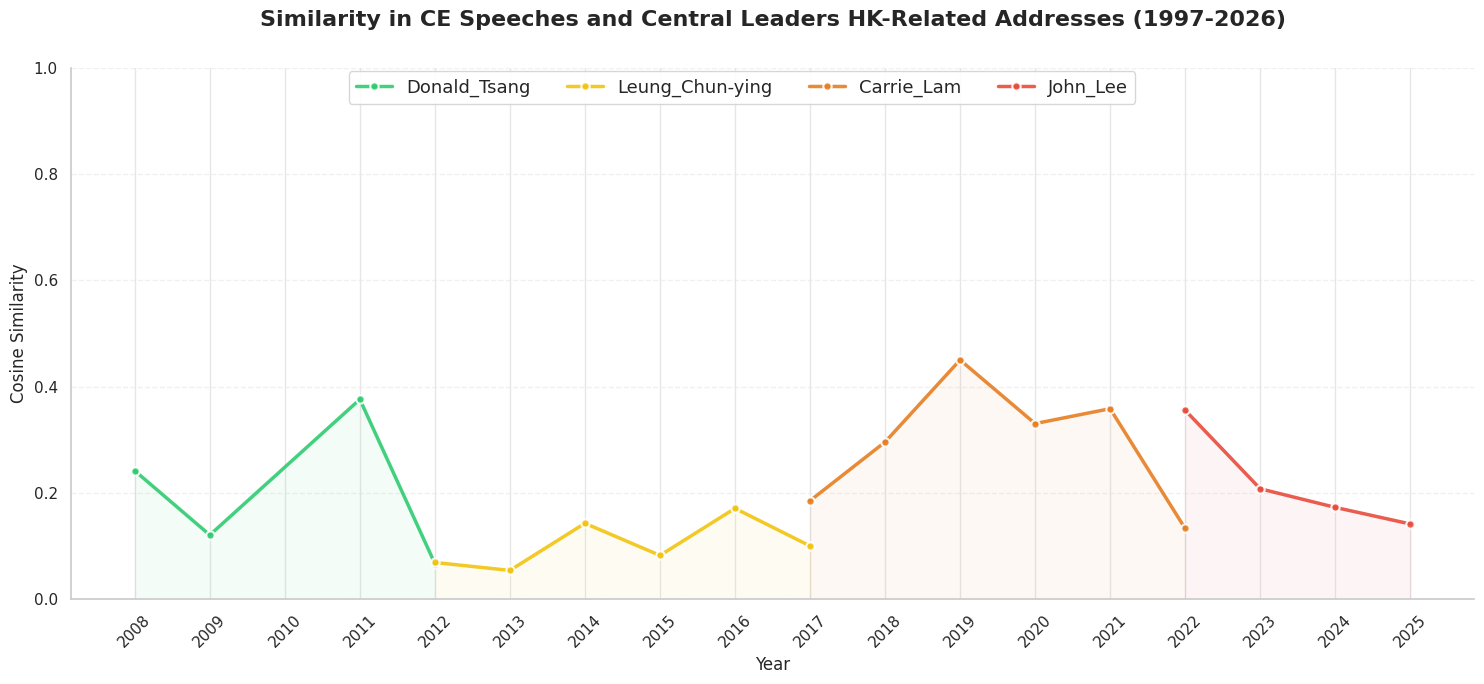

In [12]:
import os
import glob
import re
import pandas as pd
import numpy as np
from datetime import datetime
import jieba
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# 1. 设定路径（支持 Colab 或本地直接运行）
colab_path = "/content/drive/MyDrive/Study/HKU/POLI3148 Data Science in Politics and Public Administration/Final Project/"

current_dir = os.getcwd()
if os.path.exists(colab_path):
    project_path = colab_path
elif os.path.exists(os.path.join(current_dir, "Data", "Data_Raw")):
    project_path = current_dir
elif os.path.exists(os.path.join(current_dir, "..", "Data", "Data_Raw")):
    project_path = os.path.abspath(os.path.join(current_dir, ".."))
else:
    project_path = current_dir

central_dir = os.path.join(project_path, "Data", "Data_Raw", "Central", "Liaison_Office", "State_Leader", "Simplified_Chinese")
ce_speeches_dir = os.path.join(project_path, "Data", "Data_Raw", "Speeches_and_Articles")
ce_names = ["Tung_Chee-hwa", "Donald_Tsang", "Leung_Chun-ying", "Carrie_Lam", "John_Lee"]

def get_year_from_filename(filename):
    base = os.path.basename(filename)
    m1 = re.match(r'^(\d{1,2})-(\d{1,2})-(\d{4})_', base)
    if m1:
        return int(m1.group(3))
    m2 = re.match(r'^(\d{4})(\d{2})(\d{2})_', base)
    if m2:
        return int(m2.group(1))
    return None

# 定义政治核心词，增加其特征权重
political_keywords = loyalty_signaling_keywords

def load_and_tokenize(filepath):
    try:
        with open(filepath, 'r', encoding='utf-8') as f:
            text = f.read()
            text = re.sub(r'[^\u4e00-\u9fa5]+', '', text) 
            words = jieba.lcut(text)
            
            # 手动增加关键特征词权重：政治关键词词频放大
            boosted_words = []
            for w in words:
                boosted_words.append(w)
                if w in political_keywords:
                    # 额外增加特征使其在 TF 中更突出
                    boosted_words.extend([w, w])
            return " ".join(boosted_words)
    except Exception as e:
        return ""

print("正在处理文本并进行分词，应用全局TF-IDF与动态停用词过滤...")

central_yearly_corpus = {}
for fp in glob.glob(os.path.join(central_dir, "*.txt")):
    year = get_year_from_filename(fp)
    if not year: continue
    tokenized = load_and_tokenize(fp)
    if tokenized:
        central_yearly_corpus[year] = central_yearly_corpus.get(year, "") + " " + tokenized

ce_yearly_corpus = {ce: {} for ce in ce_names}
for ce in ce_names:
    speech_files = glob.glob(os.path.join(ce_speeches_dir, ce, "Simplified_Chinese", "*.txt"))
    for fp in speech_files:
        year = get_year_from_filename(fp)
        if not year: continue
        tokenized = load_and_tokenize(fp)
        if tokenized:
            ce_yearly_corpus[ce][year] = ce_yearly_corpus[ce].get(year, "") + " " + tokenized

all_texts = list(central_yearly_corpus.values())
for ce in ce_names:
    all_texts.extend(list(ce_yearly_corpus[ce].values()))
all_texts = [t for t in all_texts if t.strip()]

# 引入公文专属的高频废话作为停用词，削弱其产生的虚假拟合
custom_stop_words = [
    '记者', '日', '月', '年', '流感', '天气', '交通禁令', '疫情', 
    '本港', '工作', '持续', '加强', '不仅', '除了', '香港', '社会', 
    '发展', '政府', '市民', '表示', '指出', '强调', '全面', '深入', 
    '推进', '未来', '希望', '特区', '行政长官', '进一步', '支持', '共同', 
    '重要', '提供', '推动', '认为', '很多', '包括', '有关', '相关', '隔离', 
    '措施', '防控', '疫情', '病毒', '感染', '病例', '疫苗', '公共卫生', 
    '医疗资源', '社区传播', '核酸检测', '口罩', '社交距离', '封锁', '隔离', 
    '旅行限制', '疫苗','接种', '疫情防控', '公共卫生事件', '疫情形势', '疫情发展', 
    '疫情防控措施', '疫情防控工作', '疫情防控政策', '疫情防控策略', '疫情防控成效', 
    '疫情防控经验', '疫情防控挑战', '疫情防控风险', '疫情防控压力', '疫情防控责任', '疫情防控合作', '疫情防控国际合作'
]

if all_texts:
    # 结合全文库拟合，利用逆文档频率(IDF)特征自动压低全体公文中都有的内容权重
    global_vectorizer = TfidfVectorizer(
        max_df=0.85, 
        min_df=2, 
        stop_words=custom_stop_words
    )
    global_vectorizer.fit(all_texts)

records = []
all_years = sorted(list(central_yearly_corpus.keys()))

for year in all_years:
    c_text = central_yearly_corpus[year].strip()
    if not c_text:
        continue
        
    for ce in ce_names:
        ce_text = ce_yearly_corpus[ce].get(year, "").strip()
        if not ce_text:
            continue
            
        if all_texts:
            tfidf_matrix = global_vectorizer.transform([c_text, ce_text])
            similarity = cosine_similarity(tfidf_matrix[0:1], tfidf_matrix[1:2])[0][0]
            records.append({
                "Year": year,
                "CE": ce,
                "Similarity": similarity
            })

df_sim = pd.DataFrame(records)

if not df_sim.empty:
    sns.set_theme(style="whitegrid", rc={"axes.edgecolor": "0.8", "grid.color": "0.9"})
    fig, ax1 = plt.subplots(figsize=(15, 7))
    plt.rcParams['font.sans-serif'] = ['Microsoft YaHei', 'SimHei', 'PingFang SC', 'sans-serif']
    plt.rcParams['axes.unicode_minus'] = False

    df_yearly = df_sim.groupby('Year').agg({'Similarity': 'mean'}).reset_index()

    ce_colors = {
        "Tung_Chee-hwa": "#3498DB",
        "Donald_Tsang": "#2ECC71",
        "Leung_Chun-ying": "#F1C40F",
        "Carrie_Lam": "#E67E22",
        "John_Lee": "#E74C3C",
    }

    for ce_name in df_sim['CE'].unique():
        df_sub = df_sim[df_sim['CE'] == ce_name].sort_values('Year')
        color = ce_colors.get(ce_name, "#9B59B6")
        ax1.plot(
            df_sub['Year'],
            df_sub['Similarity'],
            marker='o',
            markersize=6,
            linewidth=2.5,
            markeredgecolor='white',
            markeredgewidth=1.5,
            color=color,
            label=ce_name,
            alpha=0.9,
            zorder=5
        )
        ax1.fill_between(
            df_sub['Year'],
            0,
            df_sub['Similarity'],
            color=color,
            alpha=0.05,
            zorder=2
        )

    min_year = int(df_sim['Year'].min())
    max_year = int(df_sim['Year'].max())
    ax1.set_xticks(np.arange(min_year, max_year + 1))
    ax1.set_xticklabels(np.arange(min_year, max_year + 1), rotation=45)
    ax1.tick_params(axis='both', which='major', labelsize=11)

    ax1.set_xlabel('Year', fontsize=12)
    ax1.set_ylabel('Cosine Similarity', fontsize=12)
    ax1.set_ylim(0, 1)
    plt.title('Similarity in CE Speeches and Central Leaders HK-Related Addresses (1997-2026)', fontsize=16, fontweight="bold", pad=30)
    
    handles, labels = ax1.get_legend_handles_labels()
    fig.legend(
        handles,
        labels,
        loc='upper center',
        ncol=min(len(labels), 5),
        frameon=True,
        framealpha=0.9,
        edgecolor='lightgray',
        fontsize=13,
        bbox_to_anchor=(0.5, 0.9)
    )

    ax1.grid(axis="y", linestyle="--", alpha=0.6)
    sns.despine(ax=ax1, top=True, right=True)
    plt.tight_layout()
    plt.show()
else:
    print("未在同一年份找到既有特首发言也有中央领导人发言的内容，无法进行比较。")

In [13]:
import os
import glob
from sklearn.metrics.pairwise import cosine_similarity
import pandas as pd
import scipy.stats as stats

# 假设 global_vectorizer 已经通过 all_texts fit 好了
# central_yearly_corpus 依然是按年份汇总的中央文本字典

records_per_doc = []

for ce in ce_names:
    speech_files = glob.glob(os.path.join(ce_speeches_dir, ce, "Simplified_Chinese", "*.txt"))
    for fp in speech_files:
        year = get_year_from_filename(fp)
        if not year or year not in central_yearly_corpus: 
            continue
            
        ce_doc_text = load_and_tokenize(fp).strip()
        if not ce_doc_text:
            continue
            
        # 提取当年的中央文本作为比对基准
        c_text = central_yearly_corpus[year]
        
        # 将单篇特首文章与当年中央文本进行 TF-IDF 转化并计算相似度
        tfidf_matrix = global_vectorizer.transform([c_text, ce_doc_text])
        similarity = cosine_similarity(tfidf_matrix[0:1], tfidf_matrix[1:2])[0][0]
        
        records_per_doc.append({
            "CE": ce,
            "Year": year,
            "Filename": os.path.basename(fp),
            "Similarity": similarity
        })

# 得到以“单篇文章”为观测值的大样本 DataFrame
df_doc_sim = pd.DataFrame(records_per_doc)
print(f"成功提取了 {len(df_doc_sim)} 篇单篇发言的相似度数据！")


import itertools

# 打印各特首的单篇样本量描述性统计
print("========== 描述性统计 (基于单篇发言) ==========")
desc_stats = df_doc_sim.groupby('CE')['Similarity'].agg(['count', 'mean', 'std', 'median']).reset_index()
print(desc_stats.to_string())
print("\n")

print("========== 两两显著性检验 (Welch's t-test) ==========")
# 获取所有特首名单
unique_ces = df_doc_sim['CE'].unique()

# 对特首进行两两组合
comparisons = list(itertools.combinations(unique_ces, 2))

results = []
for ce1, ce2 in comparisons:
    sim1 = df_doc_sim[df_doc_sim['CE'] == ce1]['Similarity'].values
    sim2 = df_doc_sim[df_doc_sim['CE'] == ce2]['Similarity'].values
    
    # 执行 Welch's t-test (equal_var=False)
    t_stat, p_val = stats.ttest_ind(sim1, sim2, equal_var=False)
    
    # 显著性星号标注
    if p_val < 0.001: sig = '***'
    elif p_val < 0.01: sig = '**'
    elif p_val < 0.05: sig = '*'
    else: sig = 'ns' # Not significant
        
    results.append({
        "Comparison": f"{ce1} vs {ce2}",
        "t-statistic": round(t_stat, 3),
        "p-value": p_val,
        "Significance": sig
    })

# 输出检验结果表
df_results = pd.DataFrame(results)
print(df_results.to_string())

成功提取了 1947 篇单篇发言的相似度数据！
========== 描述性统计 (基于单篇发言) ==========
                CE  count      mean       std    median
0       Carrie_Lam    646  0.086994  0.087909  0.056141
1     Donald_Tsang    182  0.079125  0.102760  0.031541
2         John_Lee    671  0.060401  0.057978  0.043050
3  Leung_Chun-ying    448  0.035327  0.039404  0.024676


========== 两两显著性检验 (Welch's t-test) ==========
                        Comparison  t-statistic       p-value Significance
0  Donald_Tsang vs Leung_Chun-ying        5.586  7.424603e-08          ***
1       Donald_Tsang vs Carrie_Lam       -0.941  3.477542e-01           ns
2         Donald_Tsang vs John_Lee        2.358  1.925631e-02            *
3    Leung_Chun-ying vs Carrie_Lam      -13.154  1.909328e-36          ***
4      Leung_Chun-ying vs John_Lee       -8.613  2.397059e-17          ***
5           Carrie_Lam vs John_Lee        6.455  1.613687e-10          ***


# 5. 修改日期格式

In [14]:
import os
import re
import csv
import glob

# 批量修复所有历任特首原本下载的CSV和TXT文件名，统一格式为 DD-MM-YYYY
base_dir = "/content/drive/MyDrive/Study/HKU/POLI3148 Data Science in Politics and Public Administration/Final Project/Data/Data_Raw/Central/Liaison_Office"
# 若在本地Windows执行，请取消下面这行的注释并修改盘符
# base_dir = "g:/My Drive/Study/HKU/POLI3148 Data Science in Politics and Public Administration/Final Project/Data/Data_Raw/Press_Release"

leaders = ["State_Leader", "Policy"]
langs = ["Traditional_Chinese", "Simplified_Chinese"]

def pad_date(date_str):
    # 匹配 YYYY-M-D 格式
    m = re.match(r'^(\d{4})[./\-](\d{1,2})[./\-](\d{1,2})$', date_str)
    if m:
        return f"{int(m.group(3)):02d}-{int(m.group(2)):02d}-{m.group(1)}"
    # 匹配 D-M-YYYY 格式
    m2 = re.match(r'^(\d{1,2})[./\-](\d{1,2})[./\-](\d{4})$', date_str)
    if m2:
        return f"{int(m2.group(1)):02d}-{int(m2.group(2)):02d}-{m2.group(3)}"
    return date_str

def fix_csv_and_files(folder):
    if not os.path.exists(folder):
        return
    csv_file = os.path.join(folder, "Press_Release_Index.csv")
    
    # 1. 重命名 txt 文件
    for filename in os.listdir(folder):
        if not filename.endswith(".txt"):
            continue
        # 提取文件名前面的日期部分 e.g., 1-2-2012_something.txt or 2017-06-30_something.txt
        m = re.match(r'^(\d{4}[./\-]\d{1,2}[./\-]\d{1,2}|\d{1,2}[./\-]\d{1,2}[./\-]\d{4})_(.+)$', filename)
        if m:
            old_date = m.group(1)
            rest = m.group(2)
            new_date = pad_date(old_date)
            if old_date != new_date:
                old_path = os.path.join(folder, filename)
                new_path = os.path.join(folder, f"{new_date}_{rest}")
                if not os.path.exists(new_path):
                    os.rename(old_path, new_path)
                    print(f"Renamed file: {filename} -> {new_date}_{rest}")
                else:
                    # 如果新名字已存在，说明原来下载重叠了
                    os.remove(old_path)

    # 2. 修复 CSV
    if os.path.exists(csv_file):
        changed = False
        with open(csv_file, 'r', encoding='utf-8-sig', newline='') as f:
            lines = f.readlines()
            
        if not lines:
            return
            
        new_lines = []
        for line in lines:
            if ';' in line:
                parts = line.split(';', 1)
                d = parts[0].strip()
                new_d = pad_date(d)
                if d != new_d:
                    changed = True
                new_lines.append(f"{new_d}; {parts[1].strip()}\n")
            else:
                new_lines.append(line)
                
        if changed:
            with open(csv_file, 'w', encoding='utf-8-sig', newline='') as f:
                f.writelines(new_lines)
            print(f"Fixed dates in CSV: {csv_file}")

# 执行批量修复
for leader in leaders:
    for lang in langs:
        fix_csv_and_files(os.path.join(base_dir, leader, lang))

print("🎉 全部本地文件名和CSV日期修正完毕！所有日期已统一强制为 DD-MM-YYYY。")

🎉 全部本地文件名和CSV日期修正完毕！所有日期已统一强制为 DD-MM-YYYY。
